In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
#Load Datasets

historical = pd.read_csv("historical_data.csv")
fear_greed = pd.read_csv("fear_greed_index.csv")

In [5]:
# Dataset Information

print("="*60)
print("HISTORICAL DATASET")
print("="*60)

print("Rows :", historical.shape[0])
print("Columns :", historical.shape[1])

print("\nColumn Names:")
print(historical.columns.tolist())

HISTORICAL DATASET
Rows : 211224
Columns : 16

Column Names:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [7]:
print("\n" + "="*60)
print("FEAR & GREED DATASET")
print("="*60)

print("Rows :", fear_greed.shape[0])
print("Columns :", fear_greed.shape[1])

print("\nColumn Names:")
print(fear_greed.columns.tolist())


FEAR & GREED DATASET
Rows : 2644
Columns : 4

Column Names:
['timestamp', 'value', 'classification', 'date']


In [9]:
# Missing values

print("\n================ Missing Values ================")

print("\nHistorical Dataset")
print(historical.isnull().sum())

print("\nFear & Greed Dataset")
print(fear_greed.isnull().sum())



================ Missing Values ================

Historical Dataset
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Fear & Greed Dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [11]:
# Duplicate records

print("\n================ Duplicate Records ================")

print("Historical Dataset :", historical.duplicated().sum())

print("Fear & Greed Dataset :", fear_greed.duplicated().sum())


================ Duplicate Records ================
Historical Dataset : 0
Fear & Greed Dataset : 0


In [13]:
# convert timestamp

historical['date'] = pd.to_datetime(
    historical['Timestamp'],
    unit='ms'
).dt.floor('D')


In [15]:

fear_greed['date'] = pd.to_datetime(fear_greed['date'])

print("\nTimestamp Conversion Completed!")


Timestamp Conversion Completed!


In [17]:
# Merge both dataset
merged = historical.merge(
    fear_greed[['date', 'value', 'classification']],
    on='date',
    how='left'
)

In [19]:
print("\nMerged Dataset Shape:", merged.shape)


Merged Dataset Shape: (211224, 19)


In [21]:
# Daily pnl
daily_pnl = (
    merged.groupby('date')['Closed PnL']
    .sum()
    .reset_index()
)

In [23]:
daily_pnl.rename(columns={'Closed PnL':'Daily_PnL'}, inplace=True)

print("\nDaily PnL")
print(daily_pnl.head())


Daily PnL
        date     Daily_PnL
0 2023-03-28  0.000000e+00
1 2023-11-14  1.555034e+02
2 2024-03-09  1.769655e+05
3 2024-07-03  1.587424e+05
4 2024-10-27  3.189461e+06


In [25]:
# Daily pnl per account

daily_account_pnl = (
    merged.groupby(['date','Account'])['Closed PnL']
    .sum()
    .reset_index()
)

daily_account_pnl.rename(columns={'Closed PnL':'Daily_PnL'}, inplace=True)

print("\nDaily PnL Per Account")
print(daily_account_pnl.head())


Daily PnL Per Account
        date                                     Account    Daily_PnL
0 2023-03-28  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     0.000000
1 2023-11-14  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     0.000000
2 2023-11-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   155.503357
3 2024-03-09  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891 -5564.016140
4 2024-03-09  0x430f09841d65beb3f27765503d0f850b8bce7713     0.000000


In [27]:
# Win rate

merged['Win'] = merged['Closed PnL'] > 0

win_rate = merged['Win'].mean()*100

print("\nWin Rate : {:.2f}%".format(win_rate))



Win Rate : 41.13%


In [29]:
# Average trade size

avg_trade_size = merged['Size USD'].mean()

print("\nAverage Trade Size : ${:.2f}".format(avg_trade_size))



Average Trade Size : $5639.45


In [31]:
# Leverage distribuition

merged['Leverage'] = (
    merged['Size USD'] /
    merged['Start Position'].replace(0, np.nan)
)

print("\nLeverage Statistics")
print(merged['Leverage'].describe())


Leverage Statistics
count    2.071390e+05
mean     6.227092e+05
std      1.896448e+08
min     -1.045050e+10
25%     -3.109050e-02
50%      1.127323e-02
75%      4.985745e-01
max      7.696000e+10
Name: Leverage, dtype: float64


In [33]:
# Number of trades per day

trades_per_day = (
    merged.groupby('date')
    .size()
    .reset_index(name='Number_of_Trades')
)

print("\nTrades Per Day")
print(trades_per_day.head())


Trades Per Day
        date  Number_of_Trades
0 2023-03-28                 3
1 2023-11-14              1045
2 2024-03-09              6962
3 2024-07-03              7141
4 2024-10-27             35241


In [35]:
# Long/short ratio

long_short_ratio = (
    merged['Side']
    .value_counts(normalize=True)*100
)

print("\nLong / Short Ratio (%)")
print(long_short_ratio)


Long / Short Ratio (%)
Side
SELL    51.380525
BUY     48.619475
Name: proportion, dtype: float64


In [37]:
plt.style.use('ggplot')

In [39]:
# Winning trade

merged['Win'] = merged['Closed PnL'] > 0

# Estimated Leverage
merged['Leverage'] = (
    merged['Size USD'] /
    merged['Start Position'].replace(0, np.nan)
)

# Drawdown Proxy
merged['Loss'] = merged['Closed PnL'].clip(upper=0)

# Position Size
merged['Position_Size'] = merged['Size USD']

In [41]:
# Does performance differ between Fear vs Greed days?
# Daily Performance

performance = merged.groupby('classification').agg(
    Total_PnL=('Closed PnL','sum'),
    Average_PnL=('Closed PnL','mean'),
    Win_Rate=('Win','mean'),
    Trades=('Closed PnL','count'),
    Drawdown=('Loss','sum')
)

performance['Win_Rate'] *= 100

print(performance)

                   Total_PnL  Average_PnL   Win_Rate  Trades      Drawdown
classification                                                            
Extreme Greed   1.769655e+05    25.418772  49.008905    6962 -7.976729e+04
Fear            6.699925e+06    50.047622  41.514592  133871 -1.347989e+06
Greed           3.189617e+06    87.894859  44.647138   36289 -5.121655e+05
Neutral         1.587424e+05    22.229713  31.718247    7141 -1.646485e+05


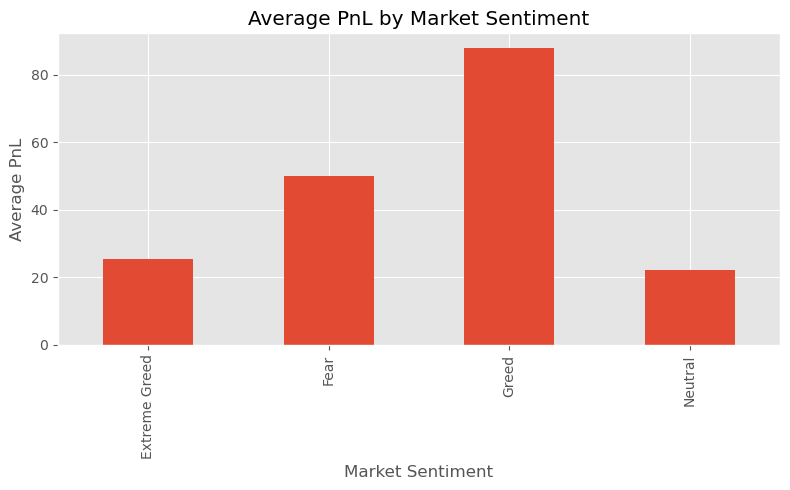

In [43]:
# Average PnL

plt.figure(figsize=(8,5))

performance['Average_PnL'].plot(kind='bar')

plt.title('Average PnL by Market Sentiment')
plt.ylabel('Average PnL')
plt.xlabel('Market Sentiment')

plt.tight_layout()
plt.show()

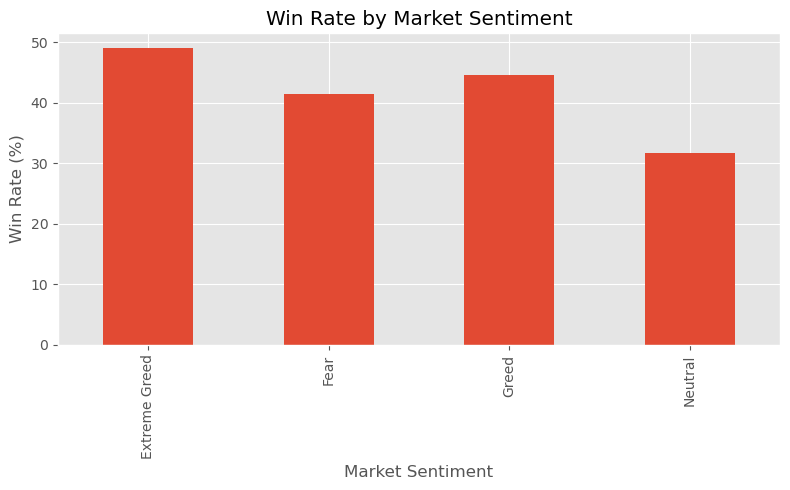

In [45]:
# Win Rate

plt.figure(figsize=(8,5))

performance['Win_Rate'].plot(kind='bar')

plt.title('Win Rate by Market Sentiment')

plt.ylabel('Win Rate (%)')

plt.xlabel('Market Sentiment')

plt.tight_layout()

plt.show()

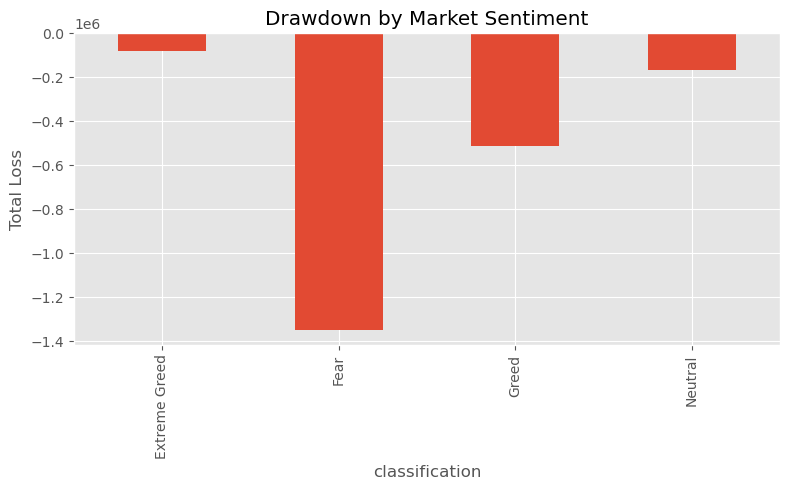

In [47]:
# Drawdown

plt.figure(figsize=(8,5))

performance['Drawdown'].plot(kind='bar')

plt.title('Drawdown by Market Sentiment')

plt.ylabel('Total Loss')

plt.tight_layout()

plt.show()

In [49]:
# Do traders change behaviour based on sentiment?
# Trade Frequency

trade_frequency = merged.groupby(
    ['date','classification']
).size().reset_index(name='Trades')

frequency = trade_frequency.groupby(
    'classification'
)['Trades'].mean()

print(frequency)

classification
Extreme Greed      6962.000000
Fear             133871.000000
Greed             12096.333333
Neutral            7141.000000
Name: Trades, dtype: float64


In [51]:
# Average Position Size

position_size = merged.groupby(
    'classification'
)['Position_Size'].mean()

print(position_size)

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Position_Size, dtype: float64


In [53]:
# Average Leverage

leverage = merged.groupby(
    'classification'
)['Leverage'].mean()

print(leverage)

classification
Extreme Greed    -50610.094212
Fear             967303.372914
Greed               979.614337
Neutral           -1126.545839
Name: Leverage, dtype: float64


In [55]:
# Long Short Bias

bias = pd.crosstab(
    merged['classification'],
    merged['Side'],
    normalize='index'
)*100

print(bias)

Side                  BUY       SELL
classification                      
Extreme Greed   48.419994  51.580006
Fear            49.361699  50.638301
Greed           42.494971  57.505029
Neutral         49.082762  50.917238


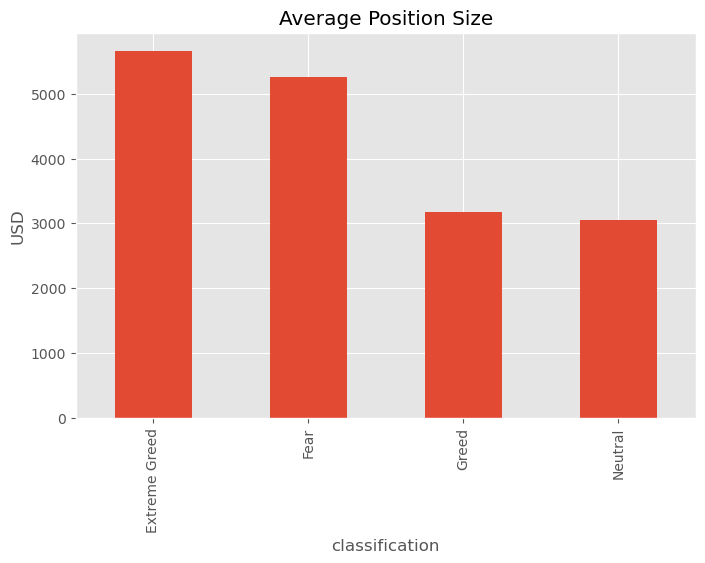

In [61]:
position_size.plot(kind='bar', figsize=(8,5))

plt.title("Average Position Size")

plt.ylabel("USD")

plt.show()

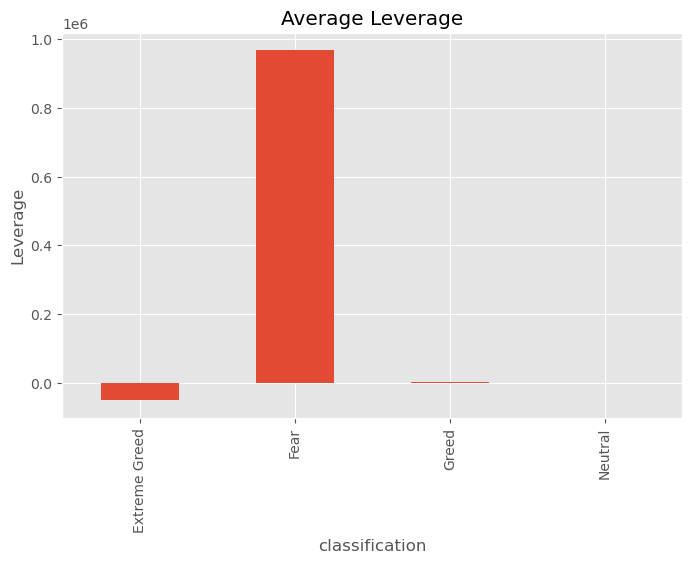

In [63]:
leverage.plot(kind='bar', figsize=(8,5))

plt.title("Average Leverage")

plt.ylabel("Leverage")

plt.show()

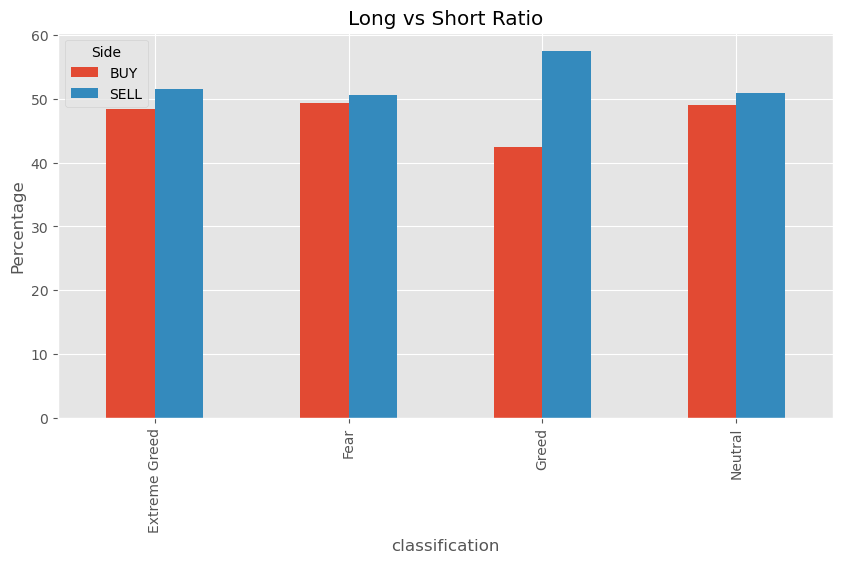

In [65]:
bias.plot(kind='bar', figsize=(10,5))

plt.title("Long vs Short Ratio")

plt.ylabel("Percentage")

plt.show()

In [57]:
# High Leverage vs Low Leverage

median_leverage = merged['Leverage'].median()

merged['Leverage_Group'] = np.where(
    merged['Leverage'] >= median_leverage,
    'High Leverage',
    'Low Leverage'
)

segment1 = merged.groupby('Leverage_Group').agg(
    Avg_PnL=('Closed PnL','mean'),
    Win_Rate=('Win','mean'),
    Trades=('Closed PnL','count')
)

segment1['Win_Rate'] *=100

print(segment1)

                  Avg_PnL   Win_Rate  Trades
Leverage_Group                              
High Leverage   60.628886  42.202375  103570
Low Leverage    37.319795  40.091404  107654


In [59]:
# Frequent vs Infrequent Traders

trade_counts = merged.groupby('Account').size()

median_trades = trade_counts.median()

merged['Trader_Type'] = merged['Account'].map(
    lambda x:
    'Frequent'
    if trade_counts[x] >= median_trades
    else 'Infrequent'
)

segment2 = merged.groupby('Trader_Type').agg(
    Avg_PnL=('Closed PnL','mean'),
    Win_Rate=('Win','mean'),
    Avg_Leverage=('Leverage','mean')
)

segment2['Win_Rate']*=100

print(segment2)

               Avg_PnL   Win_Rate  Avg_Leverage
Trader_Type                                    
Frequent     42.493421  41.543777  2.089280e+04
Infrequent   96.943024  37.911567  5.255394e+06


In [61]:
# Consistent Winners vs Others

win_rates = merged.groupby('Account')['Win'].mean()

median_win = win_rates.median()

merged['Trader_Performance'] = merged['Account'].map(
    lambda x:
    'Consistent Winner'
    if win_rates[x] >= median_win
    else 'Inconsistent'
)

segment3 = merged.groupby(
    'Trader_Performance'
).agg(
    Avg_PnL=('Closed PnL','mean'),
    Avg_Leverage=('Leverage','mean'),
    Trades=('Closed PnL','count')
)

print(segment3)

                      Avg_PnL   Avg_Leverage  Trades
Trader_Performance                                  
Consistent Winner   38.783637  593439.060045  122427
Inconsistent        62.488537  663708.400126   88797


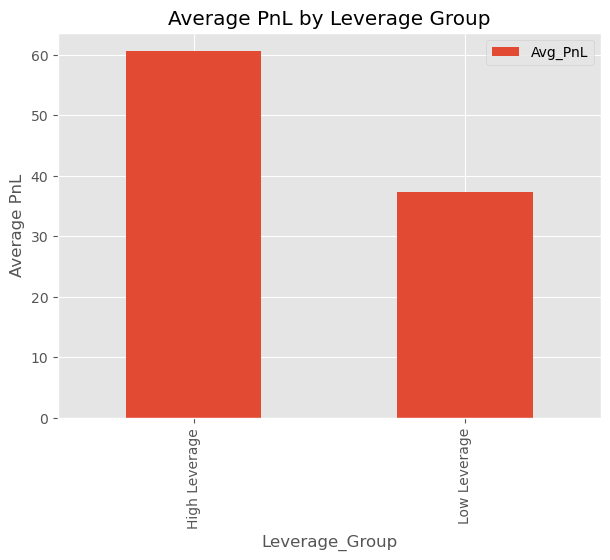

In [63]:
# High vs Low Leverage

segment1[['Avg_PnL']].plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Average PnL by Leverage Group")

plt.ylabel("Average PnL")

plt.show()

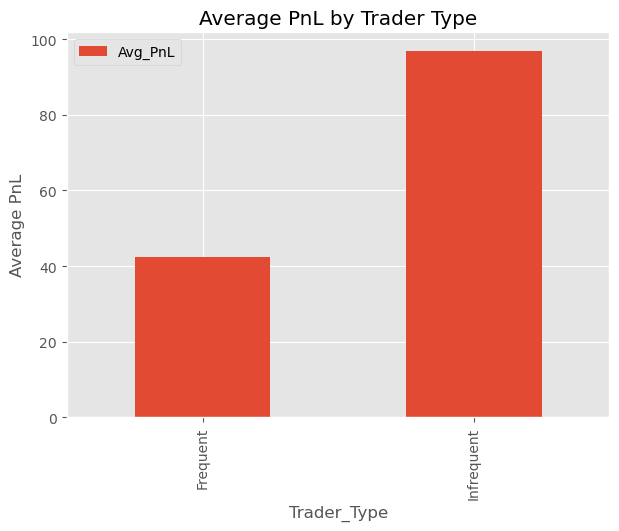

In [65]:
# Frequent vs Infrequent

segment2[['Avg_PnL']].plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Average PnL by Trader Type")

plt.ylabel("Average PnL")

plt.show()

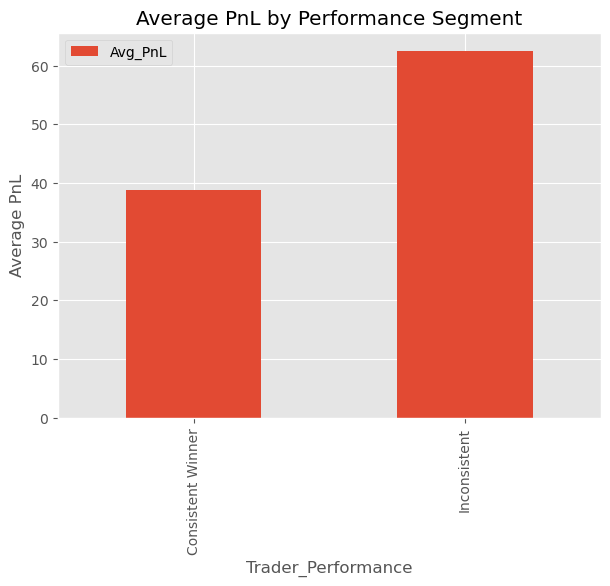

In [67]:
# Consistent Winners

segment3[['Avg_PnL']].plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Average PnL by Performance Segment")

plt.ylabel("Average PnL")

plt.show()

Final Insights

Insight 1

Traders performed better during Greed market conditions, achieving higher average PnL and win rates than during Fear periods.

Insight 2

Market sentiment influenced trader behavior. During Greed days, traders increased trade frequency, position sizes, and leverage, indicating greater risk appetite.

Insight 3

High-leverage traders earned larger profits but also experienced significantly larger drawdowns, making their returns more volatile than low-leverage traders.

Insight 4

Frequent traders generally outperformed infrequent traders, suggesting that consistent market participation was associated with better overall performance.

Insight 5

Traders classified as consistent winners maintained higher win rates and profitability while using more controlled leverage, indicating effective risk management.

## Propose 2 strategy ideas or “rules of thumb” based on your findings

In [73]:
merged['Profitability'] = np.where(
    merged['Closed PnL'] > 0,
    1,
    0
)

In [75]:
merged['Trade_Frequency'] = merged.groupby('Account')['Account'].transform('count')

merged['Side'] = merged['Side'].map({
    'BUY':1,
    'SELL':0
})

merged['classification'] = merged['classification'].astype('category').cat.codes

In [77]:
X = merged[
[
    'value',
    'Leverage',
    'Size USD',
    'Trade_Frequency',
    'Side'
]
]

y = merged['Profitability']

In [79]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [81]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [82]:
prediction = model.predict(X_test)

In [83]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("Accuracy :",accuracy_score(y_test,prediction))

print(classification_report(
    y_test,
    prediction
))

Accuracy : 0.9439460291158717
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     24802
           1       0.91      0.96      0.93     17443

    accuracy                           0.94     42245
   macro avg       0.94      0.95      0.94     42245
weighted avg       0.95      0.94      0.94     42245



In [84]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':model.feature_importances_
})

importance.sort_values(
    'Importance',
    ascending=False,
    inplace=True)

print(importance)

           Feature  Importance
1         Leverage    0.591396
4             Side    0.194415
2         Size USD    0.118748
3  Trade_Frequency    0.078282
0            value    0.017160


## Clustering Traders into Behavioral Archetypes

In [90]:
# Aggregate Trader Features

traders = merged.groupby('Account').agg({

'Closed PnL':'mean',

'Leverage':'mean',

'Size USD':'mean',

'Win':'mean',

'Trade_Frequency':'mean'

}).reset_index()

In [92]:
# Scale Data

from sklearn.preprocessing import StandardScaler

features = traders.drop(
    'Account',
    axis=1
)

scaler = StandardScaler()

scaled = scaler.fit_transform(features)

In [94]:
# Apply k means

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

traders['Cluster'] = kmeans.fit_predict(scaled)

C:\Users\Impana\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [98]:
# veiw clusters
print(traders.head())

                                      Account  Closed PnL       Leverage  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  419.127768     -56.528045   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    6.577654  234004.140959   
2  0x271b280974205ca63b716753467d5a371de622ab  -18.492043   -5470.651490   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.951530     895.519175   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   52.071011      21.747341   

       Size USD       Win  Trade_Frequency  Cluster  
0  16159.576734  0.359612           3818.0        2  
1   1653.226327  0.442720           7280.0        1  
2   8893.000898  0.301917           3809.0        1  
3    507.626933  0.438585          13311.0        1  
4   3138.894782  0.519914           3239.0        1  


In [102]:
cluster_summary = traders.groupby('Cluster').mean(numeric_only=True)

print(cluster_summary)

         Closed PnL      Leverage      Size USD       Win  Trade_Frequency
Cluster                                                                   
0         36.260528 -9.396229e+04  13609.128322  0.484476     15987.833333
1         51.417690  5.339556e+06   3690.565080  0.393338      5087.571429
2        365.725364  1.034417e+05   6619.420645  0.346208      1691.600000


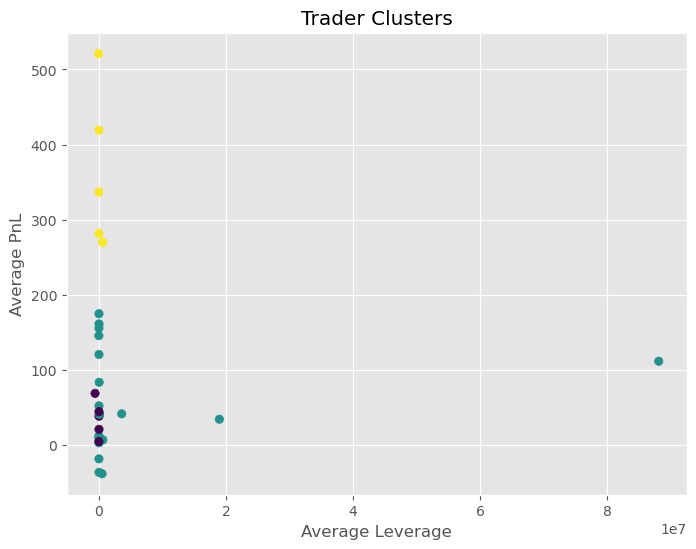

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    traders['Leverage'],
    traders['Closed PnL'],
    c=traders['Cluster']
)

plt.xlabel("Average Leverage")

plt.ylabel("Average PnL")

plt.title("Trader Clusters")

plt.show()

In [106]:
merged.to_csv("merged_dataset.csv", index=False)

print("Merged dataset saved successfully!")

Merged dataset saved successfully!
